In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import xarray_sql as xsql
from scipy.stats import chi2_contingency, ks_2samp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob

In [3]:
%pip install chardet

Note: you may need to restart the kernel to use updated packages.


In [4]:
import dask.dataframe as dd
import chardet

with open('C:/Users/dfang/Downloads/CalCOFI_Database_194903-202105_csv_16October2023/CalCOFI_Database_194903-202105_csv_16October2023/194903-202105_Bottle.csv', 'rb') as f:
    sample = f.read(100_000)

result = chardet.detect(sample)
print(result)

df = pd.read_csv('C:/Users/dfang/Downloads/CalCOFI_Database_194903-202105_csv_16October2023/CalCOFI_Database_194903-202105_csv_16October2023/194903-202105_Bottle.csv', encoding = 'ISO-8859-1')

# Computations are lazy — call .compute() to execute
#result = df.groupby('col').sum().compute()
print(df)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


C:\Users\dfang\AppData\Local\Temp\ipykernel_31424\904029434.py:10: DtypeWarning: Columns (47,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/Users/dfang/Downloads/CalCOFI_Database_194903-202105_csv_16October2023/CalCOFI_Database_194903-202105_csv_16October2023/194903-202105_Bottle.csv', encoding = 'ISO-8859-1')


        Cst_Cnt  Btl_Cnt       Sta_ID                                Depth_ID  \
0             1        1  054.0 056.0  19-4903CR-HY-060-0930-05400560-0000A-3   
1             1        2  054.0 056.0  19-4903CR-HY-060-0930-05400560-0008A-3   
2             1        3  054.0 056.0  19-4903CR-HY-060-0930-05400560-0010A-7   
3             1        4  054.0 056.0  19-4903CR-HY-060-0930-05400560-0019A-3   
4             1        5  054.0 056.0  19-4903CR-HY-060-0930-05400560-0020A-7   
...         ...      ...          ...                                     ...   
895366    35644   895394  093.3 100.0  20-21055S-MX-126-2005-09331000-0304A-3   
895367    35644   895395  093.3 100.0  20-21055S-MX-126-2005-09331000-0379A-3   
895368    35644   895396  093.3 100.0  20-21055S-MX-126-2005-09331000-0400A-7   
895369    35644   895397  093.3 100.0  20-21055S-MX-126-2005-09331000-0500A-7   
895370    35644   895398  093.3 100.0  20-21055S-MX-126-2005-09331000-0516A-3   

        Depthm  T_degC    S

In [6]:
df_cast = pd.read_csv('C:/Users/dfang/Downloads/CalCOFI_Database_194903-202105_csv_16October2023/CalCOFI_Database_194903-202105_csv_16October2023/194903-202105_Cast.csv', encoding = 'ISO-8859-1')

C:\Users\dfang\AppData\Local\Temp\ipykernel_31424\260014972.py:1: DtypeWarning: Columns (40,41,44,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cast = pd.read_csv('C:/Users/dfang/Downloads/CalCOFI_Database_194903-202105_csv_16October2023/CalCOFI_Database_194903-202105_csv_16October2023/194903-202105_Cast.csv', encoding = 'ISO-8859-1')


In [7]:
df_cast

,Cst_Cnt,Cruise_ID,Cruise,Cruz_Sta,DbSta_ID,Cast_ID,Sta_ID,Quarter,Sta_Code,Distance,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
0,1,1949-03-01-C-31CR,194903,19490305400560,5400560,19-4903CR-HY-060-0930-05400560,054.0 056.0,1,NST,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1,2,1949-03-01-C-31CR,194903,19490305200750,5200750,19-4903CR-HY-060-2112-05200750,052.0 075.0,1,NST,NaN,...,NaN,16.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN
2,3,1949-03-01-C-31CR,194903,19490305100850,5100850,19-4903CR-HY-061-0354-05100850,051.0 085.0,1,NST,NaN,...,NaN,23.0,5.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN
3,4,1949-03-01-C-31CR,194903,19490305000950,5000950,19-4903CR-HY-061-1042-05000950,050.0 095.0,1,NST,NaN,...,NaN,18.0,8.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,5,1949-03-01-C-31CR,194903,19490305001040,5001040,19-4903CR-HY-061-1706-05001040,050.0 104.0,1,NST,NaN,...,NaN,27.0,13.0,NaN,NaN,NaN,7.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35639,35640,2021-05-04-C-325S,202105,20210509330600,9330600,20-21055S-MX-125-22:02-09330600,093.3 060.0,2,ST,-134.591,...,8.0,21.0,3.0,1015.8,14.2,12.8,2.0,6.0,8.0,7.0
35640,35641,2021-05-04-C-325S,202105,20210509330700,9330700,20-21055S-MX-126-03:43-09330700,093.3 070.0,2,ST,-174.357,...,NaN,30.0,7.0,1015.4,13.6,12.5,NaN,NaN,NaN,NaN
35641,35642,2021-05-04-C-325S,202105,20210509330800,9330800,20-21055S-MX-126-09:09-09330800,093.3 080.0,2,ST,-214.705,...,NaN,35.0,6.0,1016.9,12.7,11.8,NaN,NaN,NaN,NaN
35642,35643,2021-05-04-C-325S,202105,20210509330900,9330900,20-21055S-MX-126-14:32-09330900,093.3 090.0,2,ST,-254.377,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0


In [8]:
df_total = pd.merge(df, df_cast, on = 'Cst_Cnt')
df_total

,Cst_Cnt,Btl_Cnt,Sta_ID_x,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.500,33.44000,NaN,25.64900,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.460,33.44000,NaN,25.65600,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.460,33.43700,NaN,25.65400,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.450,33.42000,NaN,25.64300,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.450,33.42100,NaN,25.64300,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895366,35644,895394,093.3 100.0,20-21055S-MX-126-2005-09331000-0304A-3,304,7.303,26.67160,1.526,26.67160,22.59,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0
895367,35644,895395,093.3 100.0,20-21055S-MX-126-2005-09331000-0379A-3,379,6.606,26.82726,0.843,26.82726,12.28,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0
895368,35644,895396,093.3 100.0,20-21055S-MX-126-2005-09331000-0400A-7,400,6.420,26.86069,0.733,26.86069,10.64,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0
895369,35644,895397,093.3 100.0,20-21055S-MX-126-2005-09331000-0500A-7,500,5.877,27.01054,0.393,27.01054,5.63,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0


In [9]:
print(df_total['ChlorA'].isnull().sum())
dfs = pd.notnull(df_total['ChlorA'])
df_total = df_total[dfs]
df_total

649705


,Cst_Cnt,Btl_Cnt,Sta_ID_x,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
472997,18832,472998,133.0 035.0,19-7303AX-HY-067-2005-13300350-0000B-3,0,19.230,34.49100,5.460,24.57500,103.90,...,6.0,33.0,12.0,1001.6,19.0,15.0,1.0,6.0,7.0,NaN
472998,18832,472999,133.0 035.0,19-7303AX-HY-067-2005-13300350-0010A-3,10,19.220,34.49200,5.460,24.57800,103.90,...,6.0,33.0,12.0,1001.6,19.0,15.0,1.0,6.0,7.0,NaN
473027,18833,473028,142.7 008.0,19-7303AX-HY-069-1715-14270080-0000B-3,0,20.830,34.87700,5.200,24.44800,102.10,...,NaN,33.0,7.0,1001.7,19.2,14.9,2.0,8.0,1.0,8.0
473028,18833,473029,142.7 008.0,19-7303AX-HY-069-1715-14270080-0010A-3,10,20.160,34.91100,4.740,24.65300,92.00,...,NaN,33.0,7.0,1001.7,19.2,14.9,2.0,8.0,1.0,8.0
473030,18833,473031,142.7 008.0,19-7303AX-HY-069-1715-14270080-0030A-3,30,19.370,34.94300,4.120,24.88500,78.80,...,NaN,33.0,7.0,1001.7,19.2,14.9,2.0,8.0,1.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895359,35644,895387,093.3 100.0,20-21055S-MX-126-2005-09331000-0100A-3,100,11.320,25.64753,4.681,25.64753,75.59,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0
895360,35644,895388,093.3 100.0,20-21055S-MX-126-2005-09331000-0125A-7,125,9.827,26.02236,3.513,26.02236,54.95,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0
895361,35644,895389,093.3 100.0,20-21055S-MX-126-2005-09331000-0150A-7,150,9.403,26.19182,2.986,26.19182,46.30,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0
895362,35644,895390,093.3 100.0,20-21055S-MX-126-2005-09331000-0151A-3,151,9.359,26.20768,2.973,26.20768,46.05,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0


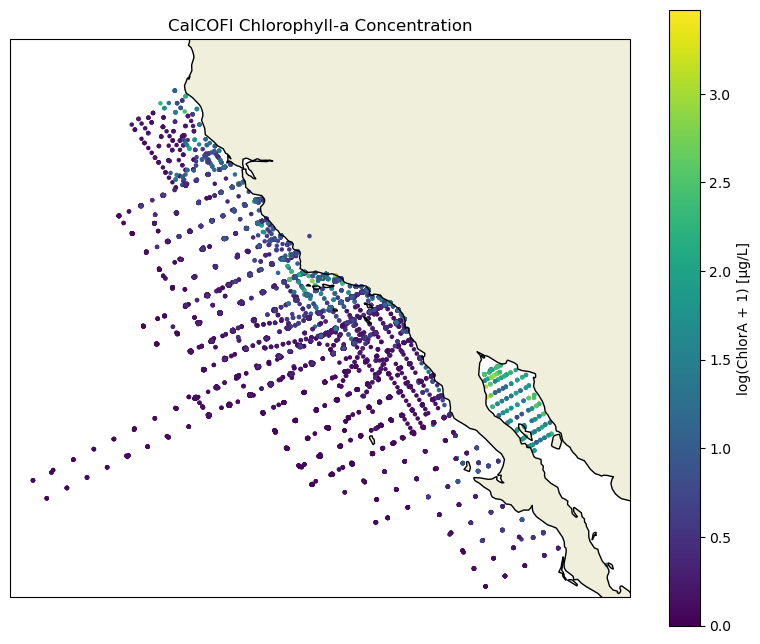

In [19]:
#Spatial Analysis of Chlorophyll Concentrations across lat-lons
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Filter out NaN and bad quality data first (see quality note below)
#df_clean = df_total[df_total['Chlqua'].isin([0, 1])].dropna(subset=['ChlorA', 'Lat_Dec', 'Lon_Dec'])
df_clean = df_total[df_total['Depthm'].between(10, 20)]

sc = ax.scatter(
    df_clean['Lon_Dec'],
    df_clean['Lat_Dec'],
    c=np.log1p(df_clean['ChlorA']),  # log scale — chlorophyll is skewed
    cmap='viridis',
    s=5,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.set_extent([-130, -110, 24, 42])  # CalCOFI domain

plt.colorbar(sc, label='log(ChlorA + 1) [µg/L]')
plt.title('CalCOFI Chlorophyll-a Concentration')
plt.show()

In [20]:
df_clean

,Cst_Cnt,Btl_Cnt,Sta_ID_x,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
472998,18832,472999,133.0 035.0,19-7303AX-HY-067-2005-13300350-0010A-3,10,19.220,34.49200,5.460,24.57800,103.90,...,6.0,33.0,12.0,1001.6,19.0,15.0,1.0,6.0,7.0,NaN
473028,18833,473029,142.7 008.0,19-7303AX-HY-069-1715-14270080-0010A-3,10,20.160,34.91100,4.740,24.65300,92.00,...,NaN,33.0,7.0,1001.7,19.2,14.9,2.0,8.0,1.0,8.0
473073,18835,473074,120.0 010.0,19-7303AX-HY-070-2314-12000100-0010A-3,10,16.600,NaN,3.620,NaN,NaN,...,1.0,12.0,15.0,1001.0,18.8,14.0,1.0,8.0,1.0,NaN
473074,18835,473075,120.0 010.0,19-7303AX-HY-070-2314-12000100-0020A-7,20,16.220,NaN,3.740,NaN,NaN,...,1.0,12.0,15.0,1001.0,18.8,14.0,1.0,8.0,1.0,NaN
473098,18836,473099,120.0 009.0,19-7303AX-HY-071-0216-12000090-0010A-3,10,16.930,NaN,5.320,NaN,NaN,...,2.0,13.0,10.0,1000.8,18.9,15.2,1.0,6.0,1.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895327,35643,895355,093.3 090.0,20-21055S-MX-126-1432-09330900-0010A-7,10,14.952,24.68585,6.007,24.68585,104.42,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0
895328,35643,895356,093.3 090.0,20-21055S-MX-126-1432-09330900-0011A-3,11,14.975,24.68526,6.022,24.68526,104.73,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0
895329,35643,895357,093.3 090.0,20-21055S-MX-126-1432-09330900-0020A-7,20,14.528,24.79401,6.036,24.79401,104.03,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0
895351,35644,895379,093.3 100.0,20-21055S-MX-126-2005-09331000-0010A-3,10,15.307,24.58595,5.905,24.58595,103.37,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0


In [21]:
df_clean = df_clean.drop_duplicates()
dfs1 = pd.notnull(df_clean['Salnty'])
df_cleaned = df_clean[dfs1]
dfs2 = pd.notnull(df_cleaned['T_degC'])
df_cleaned = df_cleaned[dfs2]
df_cleaned

,Cst_Cnt,Btl_Cnt,Sta_ID_x,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
472998,18832,472999,133.0 035.0,19-7303AX-HY-067-2005-13300350-0010A-3,10,19.220,34.49200,5.460,24.57800,103.90,...,6.0,33.0,12.0,1001.6,19.0,15.0,1.0,6.0,7.0,NaN
473028,18833,473029,142.7 008.0,19-7303AX-HY-069-1715-14270080-0010A-3,10,20.160,34.91100,4.740,24.65300,92.00,...,NaN,33.0,7.0,1001.7,19.2,14.9,2.0,8.0,1.0,8.0
473377,18848,473378,106.7 002.0,19-7303AX-HY-073-0643-10670020-0010A-3,10,17.320,35.59600,5.800,25.89600,107.10,...,4.0,28.0,25.0,1000.8,17.3,12.0,0.0,NaN,NaN,NaN
473384,18849,473385,106.7 004.0,19-7303AX-HY-073-0848-10670040-0010A-3,10,17.120,35.53800,5.730,25.90000,105.40,...,4.0,29.0,26.0,1000.7,15.0,11.0,1.0,8.0,1.0,9.0
473386,18849,473387,106.7 004.0,19-7303AX-HY-073-0848-10670040-0020A-7,20,17.130,35.53100,5.730,25.89300,105.40,...,4.0,29.0,26.0,1000.7,15.0,11.0,1.0,8.0,1.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895327,35643,895355,093.3 090.0,20-21055S-MX-126-1432-09330900-0010A-7,10,14.952,24.68585,6.007,24.68585,104.42,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0
895328,35643,895356,093.3 090.0,20-21055S-MX-126-1432-09330900-0011A-3,11,14.975,24.68526,6.022,24.68526,104.73,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0
895329,35643,895357,093.3 090.0,20-21055S-MX-126-1432-09330900-0020A-7,20,14.528,24.79401,6.036,24.79401,104.03,...,8.0,29.0,7.0,1017.6,13.1,11.9,2.0,6.0,8.0,6.0
895351,35644,895379,093.3 100.0,20-21055S-MX-126-2005-09331000-0010A-3,10,15.307,24.58595,5.905,24.58595,103.37,...,5.0,28.0,6.0,1017.8,13.0,11.9,1.0,7.0,8.0,7.0


In [22]:
df_cleaned.to_csv('Cleaned_CalCOFI_Phytoplankton.csv', index = False)